# Wind → Wind-farm · M1 — Catalog (per-sub-peril hazard profile)

**Peril:** Wind · **Layer:** M1 (catalog) · *turns M0 evidence into the typed handoff the loss engine consumes.*

M0 met the hazard from **two data shapes**; **M1 turns each into the clean contract** the shared compound-Poisson
engine reads: a **frequency λ** + a **conditional severity distribution** on the 3-s gust, per sub-peril, per
site. Wind's twist — the catalog **forks by coupling bucket**, in one notebook:

| | **Strong / straight-line wind** (site-conditioned) | **Tornado** (areal hit-or-miss) |
|---|---|---|
| data shape (M0) | ASCE **pre-integrated RP gust surface** (`01`) | SPC **path/strike record** (`02`) |
| frequency | **read** the RP curve → λ (profile-assembly, *no fit*) — the **wildfire** pattern | **fit** λ_collection from SPC (**bias-corrected**), thinned by p_hit in M2 — the **hail** pattern |
| severity | bounded GPD on 3-s gust, the RP curve *is* the return-level | EF-mix → bounded GPD on 3-s gust |
| dispersion | fano = 1 (**structural** — RP pre-integrated it) | **fit** Fano (NegBin if over-dispersed) |

> Same typed object out of both routes — `{lambda_per_yr, fano_factor, magnitude_metric, severity_distribution,
> physical_bound_L_ms, tiv, footprint}`. The fork is **by coupling bucket, not by physics invention**: strong
> wind reuses wildfire's M1 machinery, tornado reuses hail's.

> Plan: [`m1_catalog.md`](../../../docs/plans/convective_wind/m1_catalog.md) · thresholds/bound from
> [`layer0/01_hazard_definition`](../layer0/01_hazard_definition.ipynb) · severity background:
> [`hazard_math/05`](../../../Learning/ML-DL/InfraSure_related/hazard_math/05_extreme_value_theory_tail_modeling.md).

## 0 · Intent & scope

**Does:** per sub-peril, per site — derive **λ** (strong wind: profile-assembly off the ASCE return-level curve;
tornado: bias-corrected fit from SPC), the **bounded-GPD severity** on the 3-s gust (μ-anchored, L-truncated,
ξ<0), the dispersion (fano), and the path-geometry stats (tornado, for M2); emit the typed catalog + manifest;
verify every basic against a known answer.

**Does NOT:** thin tornado λ_collection → λ_asset (that is M2's path-aware Minkowski), build the damage curve
(M3), or compute loss (M4). Strong wind is already per-site (site-conditioned, no thinning). Never back-solve
the severity from a target EAL (the old repo's rejected `mag_sim` habit) — μ_mean is fit to the curve/record.

## Assumptions (this layer)

- **AWN-15** — strong-wind λ from the **ASCE RP surface** (profile-assembly, no fit); **fano = 1 structural**
  (ASCE pre-integrated the dispersion). Pre-integration is a borrow — we inherit ASCE/NIST's vintage/terrain.
- **AWN-1** 🔴 — tornado λ_collection **fit from the bias-corrected SPC record** (a detection-stable window +
  the EF2+ robustness cross-check); the old repo's no-correction is rejected. EF is damage-inferred, rural-low.
- **AWN-17 / 18** — severity = **bounded GPD on 3-s gust** (μ-anchored, **L≈113 m/s** truncated, **ξ<0**),
  analytic solve `ξ=(μ_mean−μ)/(μ_mean−L)`, `σ=−ξ(L−μ)`; **μ_mean fit to the curve/record, NOT to an EAL.**
- **AWN-16** — strong-wind MC well-populated; tornado sparse (→ M4 reports TVaR + SE). **AWN-19** — stationary λ.

Full register: [`assumptions.md`](../../../docs/plans/convective_wind/assumptions.md).

## 1 · The typed catalog contract (what M1 emits to the engine)

One object per sub-peril per site — the exact keys M2/M4 read (a wind-shaped version of hail's
`frequency_process_params` + severity), or M4 KeyErrors:

```text
  { lambda_per_yr,                 # strong wind: per-SITE rate (final). tornado: λ_collection (REGIONAL → thin in M2)
    fano_factor,                   # 1 = Poisson; >1 = over-dispersed (NegBin); Poisson is a NegBin special case
    magnitude_metric = "3s_gust_ms",
    severity_distribution = {family:"bounded_gpd", mu, sigma, xi, L},   # ξ<0, support [μ, L]
    physical_bound_L_ms ≈ 113,     # EF5 ceiling
    tiv, footprint }               # from M0/03 geometry
```

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter, NullFormatter
from scipy.stats import genpareto

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})

MS = 0.44704                      # mph → m/s
MS_TO_MPH = 1.0 / MS
MU_W = 25.92                      # strong-wind event threshold μ (NWS severe 58 mph), m/s   [layer-0]
MU_T = 29.0                       # tornado event threshold μ (EF0, 65 mph), m/s             [layer-0]
L = 113.0                         # physical bound L (EF5 ceiling), m/s                       [layer-0, AWN-8]
EF_MID_MPH = {0: 75, 1: 98, 2: 123, 3: 150.5, 4: 183, 5: 226}        # EF-bin gust midpoints (mph)
EF_MID = {k: v * MS for k, v in EF_MID_MPH.items()}                  # → m/s
TORN_STABLE_YEAR = 1996           # post-NEXRAD detection-stable window for the λ fit (justified in §4)


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "AGENTS.md").exists():
            return p
    raise FileNotFoundError("repo root (AGENTS.md) not found")


ROOT = _repo_root()
DATA_DIR = ROOT / "data" / "convective_wind"
ASSETS = [
    {"slug": "traverse_wind_ok", "name": "Traverse Wind Energy Center", "role": "proving (high-wind)", "state": "OK"},
    {"slug": "shepherds_flat_or", "name": "Shepherds Flat", "role": "baseline (low-wind)", "state": "OR"},
]
# Pull TIV + footprint from the M0/03 geometry manifest (the %-of-TIV denominator + areal footprint).
for a in ASSETS:
    geo = json.loads((DATA_DIR / f"{a['slug']}_wind_m0_geometry_manifest.json").read_text())
    a["tiv"] = geo["tiv"]["tiv_usd"]
    a["footprint_km2"] = geo["boundary"]["area_km2"]
    a["n_turbines"] = geo["turbines"]["n_in_polygon"]
print(f"repo root: {ROOT}")
for a in ASSETS:
    print(f"  {a['name']:30s} TIV ${a['tiv']/1e6:.0f}M · {a['footprint_km2']:.0f} km² · {a['n_turbines']} turbines")

repo root: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling
  Traverse Wind Energy Center    TIV $1399M · 603 km² · 356 turbines
  Shepherds Flat                 TIV $1183M · 211 km² · 384 turbines


## 2 · Strong wind — profile-assembly from the ASCE return-level curve (the wildfire pattern, AWN-15)

The ASCE RP→gust curve **is** the EVT return-level curve (ASCE/NIST did the tail analysis). US non-hurricane
design wind is **Gumbel/log-linear in the return period**, so we fit `V(T) = c₀ + c₁·ln T` — and that *is* a
Poisson–GPD peaks-over-threshold model with **ξ = 0** (light tail): scale **σ = c₁**, and the rate of severe
(≥ μ) gusts is **λ = exp((c₀ − μ)/σ)** (the return period at which V = μ). No fit to a count, no EAL anchor —
we read the rate and the severity straight off the pre-integrated curve.

In [2]:
def strongwind_catalog(a: dict) -> dict:
    asce = pd.read_parquet(DATA_DIR / f"{a['slug']}_wind_m0_asce.parquet").dropna(subset=["gust_ms"])
    T = asce["mri_years"].to_numpy(float)
    V = asce["gust_ms"].to_numpy(float)
    c1, c0 = np.polyfit(np.log(T), V, 1)                          # V = c0 + c1·ln T
    pred = c0 + c1 * np.log(T)
    r2 = 1 - ((V - pred) ** 2).sum() / ((V - V.mean()) ** 2).sum()
    sigma = float(c1)
    lam = float(np.exp((c0 - MU_W) / c1))                          # rate of gust ≥ μ (per-site, site-conditioned)
    return {"sub_peril": "strong_wind", "T": T, "V": V, "c0": float(c0), "c1": sigma, "r2": float(r2),
            "lambda_per_yr": lam, "fano": 1.0, "mu": MU_W, "sigma": sigma, "xi": 0.0, "L": L,
            "mu_mean": MU_W + sigma, "v_1Myr": float(V.max())}


SW = {a["slug"]: strongwind_catalog(a) for a in ASSETS}
for a in ASSETS:
    s = SW[a["slug"]]
    print(f"{a['name']:30s}: log-linear R²={s['r2']:.4f} | λ(≥58mph)={s['lambda_per_yr']:.2f}/yr · "
          f"σ={s['sigma']:.2f} · ξ=0 (Gumbel) · μ_mean={s['mu_mean']:.1f} m/s · 10⁶-yr gust={s['v_1Myr']:.0f} m/s")
print(f"\n→ ξ=0 (light tail); the EF5 bound L={L} m/s is far above even the 10⁶-yr gust, so strong wind never reaches")
print("  turbine-survival/EF5 levels — the two-threshold finding (01), now quantified: strong-wind DAMAGE will be ~0.")

Traverse Wind Energy Center   : log-linear R²=0.9992 | λ(≥58mph)=0.90/yr · σ=3.58 · ξ=0 (Gumbel) · μ_mean=29.5 m/s · 10⁶-yr gust=75 m/s
Shepherds Flat                : log-linear R²=0.9995 | λ(≥58mph)=0.36/yr · σ=3.39 · ξ=0 (Gumbel) · μ_mean=29.3 m/s · 10⁶-yr gust=70 m/s

→ ξ=0 (light tail); the EF5 bound L=113.0 m/s is far above even the 10⁶-yr gust, so strong wind never reaches
  turbine-survival/EF5 levels — the two-threshold finding (01), now quantified: strong-wind DAMAGE will be ~0.


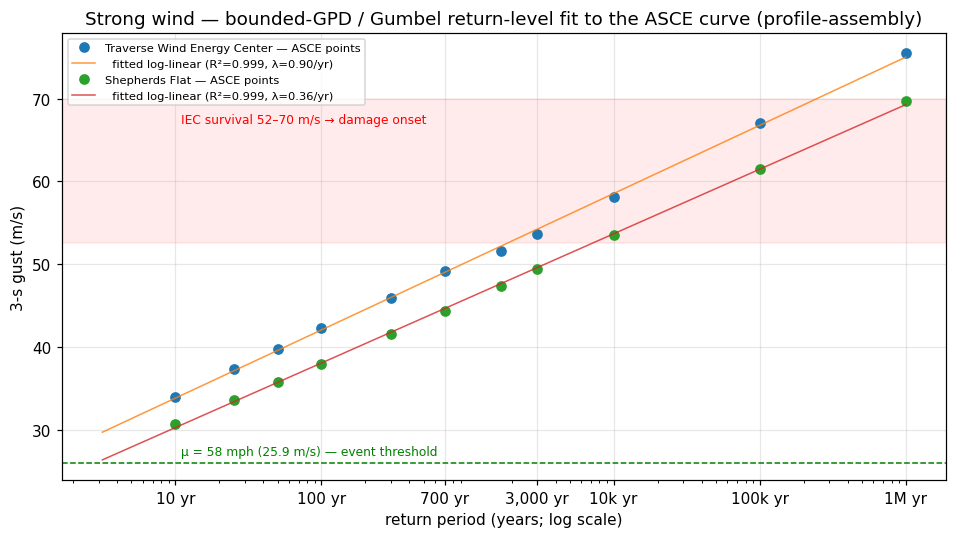

Takeaway: the fitted curve passes through the ASCE points (R²≈0.999) — the ASCE surface IS the return-level
curve, read not fitted-from-events. Both sites' design gusts stay BELOW the IEC survival band even at 1M yr,
so strong wind is a high-frequency, ~zero-damage peril here (the anchored M3 curve will return ~0 for it).


In [3]:
# Plot: the ASCE points + the fitted return-level curve (known-answer: it must pass through the points).
RP_TICKS = [10, 100, 700, 3000, 10_000, 100_000, 1_000_000]
RP_LABS = ["10 yr", "100 yr", "700 yr", "3,000 yr", "10k yr", "100k yr", "1M yr"]
IEC_LO, IEC_HI = 1.4 * 37.5, 1.4 * 50.0          # IEC survival band (m/s), class III→I
fig, ax = plt.subplots(figsize=(8.8, 5))
for a in ASSETS:
    s = SW[a["slug"]]
    Tg = np.logspace(0.5, 6, 100)
    ax.plot(s["T"], s["V"], "o", label=f"{a['name']} — ASCE points")
    ax.plot(Tg, s["c0"] + s["c1"] * np.log(Tg), "-", lw=1, alpha=0.8,
            label=f"  fitted log-linear (R²={s['r2']:.3f}, λ={s['lambda_per_yr']:.2f}/yr)")
ax.axhspan(IEC_LO, IEC_HI, color="red", alpha=0.08)
ax.text(11, IEC_HI - 3, f"IEC survival {IEC_LO:.0f}–{IEC_HI:.0f} m/s → damage onset", color="red", fontsize=8)
ax.axhline(MU_W, color="green", ls="--", lw=1)
ax.text(11, MU_W + 1, "μ = 58 mph (25.9 m/s) — event threshold", color="green", fontsize=8)
ax.set_xscale("log")
ax.xaxis.set_major_locator(FixedLocator(RP_TICKS)); ax.xaxis.set_major_formatter(FixedFormatter(RP_LABS))
ax.xaxis.set_minor_formatter(NullFormatter())
ax.set_xlabel("return period (years; log scale)"); ax.set_ylabel("3-s gust (m/s)")
ax.set_title("Strong wind — bounded-GPD / Gumbel return-level fit to the ASCE curve (profile-assembly)")
ax.legend(fontsize=7.5, loc="upper left")
plt.tight_layout(); plt.show()
print("Takeaway: the fitted curve passes through the ASCE points (R²≈0.999) — the ASCE surface IS the return-level")
print("curve, read not fitted-from-events. Both sites' design gusts stay BELOW the IEC survival band even at 1M yr,")
print("so strong wind is a high-frequency, ~zero-damage peril here (the anchored M3 curve will return ~0 for it).")

## 3 · Tornado — bias-corrected event-fit from the SPC record (the hail pattern, AWN-1)

Tornado is **areal hit-or-miss**: M1 builds the **regional** catalog (λ_collection + severity + path stats); the
thinning to the asset (`λ_asset = λ_collection · p_hit`) is M2's path-aware Minkowski. The 🔴 step is the
**bias-correction**: SPC counts are detection-biased (`02`), so a raw count is not a rate.

### 3a · λ_collection — the bias-correction, made explicit (not a silent 1996+ filter)

The bias lives in **weak (EF0/EF1)** detection rising over decades. We (a) fit λ on a **detection-stable window
(1996+, post-NEXRAD)** — *shown, justified, not silent* — and (b) cross-check with the **EF2+ rate over the full
record**, which is detection-robust *and* the turbine-relevant set (EF2 ≈ 111 mph ≈ the IEC survival onset, so
EF0/EF1 do ~0 damage anyway — the bias is concentrated in the classes that don't matter).

In [4]:
def tornado_catalog(a: dict) -> dict:
    t = pd.read_parquet(DATA_DIR / f"{a['slug']}_wind_m0_spc.parquet")
    rated = t[t.mag >= 0].copy()                                  # -9 unknown handled explicitly (excluded from rate)
    yr_max = int(t.yr.max()); yr_min = int(t.yr.min()); full_yrs = yr_max - yr_min + 1
    recent = rated[rated.yr >= TORN_STABLE_YEAR]
    win = yr_max - TORN_STABLE_YEAR + 1
    lam_coll = len(recent) / win                                  # regional rate (≤150 km), bias-stable window
    ann = recent.groupby("yr").size().reindex(range(TORN_STABLE_YEAR, yr_max + 1), fill_value=0)
    fano = float(ann.var() / ann.mean()) if ann.mean() > 0 else 1.0
    ef2p_full = float((rated.mag >= 2).sum()) / full_yrs          # detection-stable + turbine-relevant cross-check
    mix = recent["mag"].value_counts(normalize=True).sort_index()
    mu_mean = float(sum(mix.get(k, 0.0) * EF_MID[k] for k in range(6)))
    xi = (mu_mean - MU_T) / (mu_mean - L)                          # analytic bounded-GPD solve (ξ<0)
    sigma = -xi * (L - MU_T)
    # path-geometry stats per EF class (for the M2 path-aware Minkowski)
    valid = rated[(rated.len > 0) & (rated.wid > 0)]
    path = (valid.assign(area=valid.path_area_km2).groupby("ef")
            .agg(n=("ef", "size"), len_mi=("len", "median"), wid_yd=("wid", "median"), area_km2=("area", "median"))
            .round(3))
    return {"sub_peril": "tornado", "n_rated": len(rated), "yr_min": yr_min, "yr_max": yr_max,
            "lambda_collection_per_yr": lam_coll, "window": [TORN_STABLE_YEAR, yr_max], "fano": fano,
            "ef2plus_full_per_yr": ef2p_full, "ef_mix": {int(k): float(v) for k, v in mix.items()},
            "ann_counts": ann, "mu": MU_T, "mu_mean": mu_mean, "xi": float(xi), "sigma": float(sigma), "L": L,
            "rated_all": rated, "path_stats": path}


TC = {a["slug"]: tornado_catalog(a) for a in ASSETS}
for a in ASSETS:
    c = TC[a["slug"]]
    proc = "NegBin (over-dispersed)" if c["fano"] > 1.2 else "Poisson"
    print(f"{a['name']:30s}: λ_collection={c['lambda_collection_per_yr']:.2f}/yr (≤150 km, {c['window'][0]}–{c['window'][1]}) "
          f"· Fano={c['fano']:.2f} → {proc}")
    print(f"{'':32s}cross-check λ(EF2+, full {c['yr_max']-c['yr_min']+1}yr)={c['ef2plus_full_per_yr']:.3f}/yr · "
          f"severity μ_mean={c['mu_mean']:.1f} → ξ={c['xi']:.3f} σ={c['sigma']:.2f}")
print("\n→ λ_collection is REGIONAL — M2 thins it to the asset via the path-aware Minkowski (p_hit). NegBin at")
print("  Traverse = real outbreak clustering; Poisson at Shepherds Flat (so sparse it's ~memoryless).")

Traverse Wind Energy Center   : λ_collection=25.43/yr (≤150 km, 1996–2025) · Fano=12.00 → NegBin (over-dispersed)
                                cross-check λ(EF2+, full 76yr)=5.224/yr · severity μ_mean=40.4 → ξ=-0.157 σ=13.19
Shepherds Flat                : λ_collection=0.79/yr (≤150 km, 1996–2024) · Fano=1.11 → Poisson
                                cross-check λ(EF2+, full 69yr)=0.029/yr · severity μ_mean=35.3 → ξ=-0.081 σ=6.83

→ λ_collection is REGIONAL — M2 thins it to the asset via the path-aware Minkowski (p_hit). NegBin at
  Traverse = real outbreak clustering; Poisson at Shepherds Flat (so sparse it's ~memoryless).


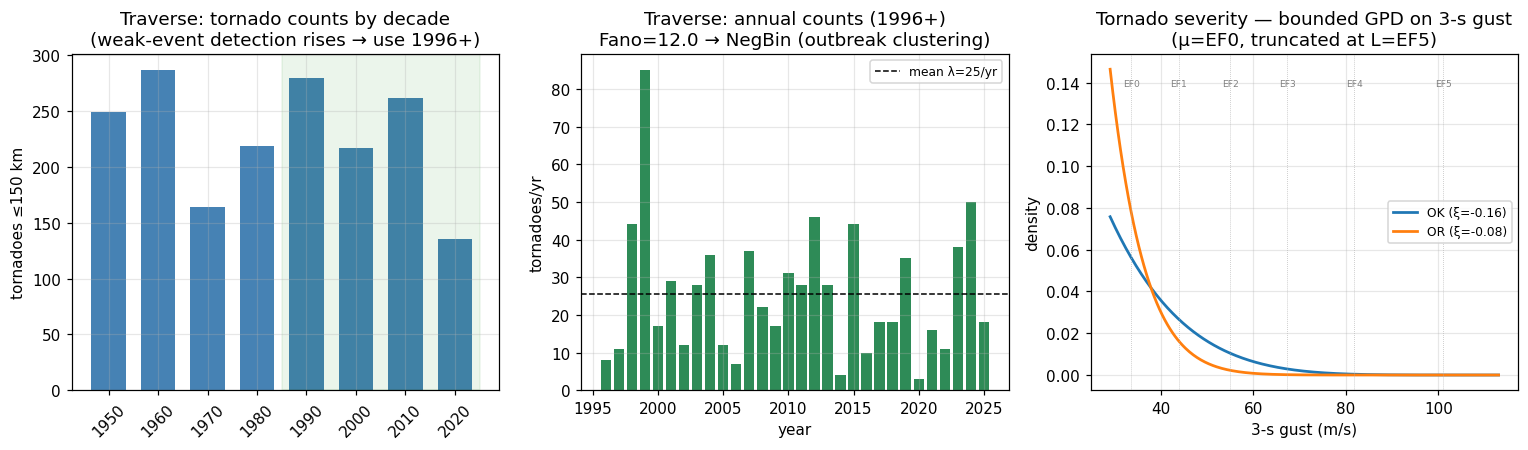

Takeaway: (L) the decadal rise is the detection bias → we fit λ on the 1996+ stable window, not the raw
full count; (M) annual counts are over-dispersed (Fano≫1) → NegBin, real tornado-outbreak clustering;
(R) the severity is a bounded GPD (ξ<0) ending at the EF5 ceiling — continuous, unlike wildfire's discrete FLP.


In [5]:
# Plot: the bias (decadal counts) + the dispersion (annual counts) + the EF severity GPD.
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
c = TC["traverse_wind_ok"]
dec = c["rated_all"].assign(dec=(c["rated_all"].yr // 10 * 10)).groupby("dec").size()
axes[0].bar(dec.index.astype(int).astype(str), dec.values, width=0.7, color="steelblue")
axes[0].axvspan(-0.5 + list(dec.index).index(1990), len(dec) - 0.5, alpha=0.08, color="green")
axes[0].set_title("Traverse: tornado counts by decade\n(weak-event detection rises → use 1996+)")
axes[0].tick_params(axis="x", rotation=45); axes[0].set_ylabel("tornadoes ≤150 km")
ann = c["ann_counts"]
axes[1].bar(ann.index, ann.values, width=0.8, color="seagreen")
axes[1].axhline(ann.mean(), color="black", ls="--", lw=1, label=f"mean λ={ann.mean():.0f}/yr")
axes[1].set_title(f"Traverse: annual counts (1996+)\nFano={c['fano']:.1f} → NegBin (outbreak clustering)")
axes[1].set_xlabel("year"); axes[1].set_ylabel("tornadoes/yr"); axes[1].legend(fontsize=8)
for a in ASSETS:
    cc = TC[a["slug"]]
    v = np.linspace(MU_T, L, 300)
    d = genpareto(c=cc["xi"], loc=MU_T, scale=cc["sigma"])
    axes[2].plot(v, d.pdf(v), lw=1.8, label=f"{a['state']} (ξ={cc['xi']:.2f})")
for ef, mid in EF_MID.items():
    axes[2].axvline(mid, color="0.7", ls=":", lw=0.5)
    axes[2].text(mid, axes[2].get_ylim()[1] * 0.9, f"EF{ef}", fontsize=6, color="0.5", ha="center")
axes[2].set_title("Tornado severity — bounded GPD on 3-s gust\n(μ=EF0, truncated at L=EF5)")
axes[2].set_xlabel("3-s gust (m/s)"); axes[2].set_ylabel("density"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()
print("Takeaway: (L) the decadal rise is the detection bias → we fit λ on the 1996+ stable window, not the raw")
print("full count; (M) annual counts are over-dispersed (Fano≫1) → NegBin, real tornado-outbreak clustering;")
print("(R) the severity is a bounded GPD (ξ<0) ending at the EF5 ceiling — continuous, unlike wildfire's discrete FLP.")

### 3b · Tornado path-geometry stats (carried to M2)

Per-EF-class median path length × width × area (km²) — the input to the M2 path-aware thin-rectangle Minkowski.

In [6]:
print("Traverse — per-EF-class tornado path geometry (median; M2 Minkowski input):")
print(TC["traverse_wind_ok"]["path_stats"].to_string())

Traverse — per-EF-class tornado path geometry (median; M2 Minkowski input):
       n  len_mi  wid_yd  area_km2
ef                                
EF0  794   0.200    27.0     0.009
EF1  592   1.500    50.0     0.132
EF2  282   3.750   100.0     0.524
EF3   91   8.800   267.0     3.237
EF4   20  21.425   880.0    27.745
EF5    3  37.000  1760.0    77.862


## 4 · Known-answer checks (basics spot-on)

In [7]:
for a in ASSETS:
    s, c = SW[a["slug"]], TC[a["slug"]]
    dw = genpareto(c=1e-9, loc=MU_W, scale=s["sigma"])            # strong wind ξ→0 (exponential)
    dt = genpareto(c=c["xi"], loc=MU_T, scale=c["sigma"])
    checks = {
        "strong-wind log-linear R² > 0.99": s["r2"] > 0.99,
        "strong-wind λ > 0": s["lambda_per_yr"] > 0,
        "tornado ξ < 0 (bounded)": c["xi"] < 0,
        "tornado severity support == [μ, L]": np.isclose(dt.support()[0], MU_T) and np.isclose(dt.support()[1], L),
        "tornado severity integrates to 1": abs(dt.cdf(L) - dt.cdf(MU_T) - 1.0) < 1e-6,
        "tornado fano >= 1": c["fano"] >= 1.0 - 1e-9,
        "strong-wind severity finite mean": np.isfinite(dw.mean()),
    }
    print(f"{a['name']}:")
    for k, v in checks.items():
        print(f"  [{'PASS' if v else 'FAIL'}] {k}")
    assert all(checks.values()), f"{a['slug']} failed a known-answer check"
print("\nall known-answer checks PASS — the catalog basics are spot-on.")

Traverse Wind Energy Center:
  [PASS] strong-wind log-linear R² > 0.99
  [PASS] strong-wind λ > 0
  [PASS] tornado ξ < 0 (bounded)
  [PASS] tornado severity support == [μ, L]
  [PASS] tornado severity integrates to 1
  [PASS] tornado fano >= 1
  [PASS] strong-wind severity finite mean
Shepherds Flat:
  [PASS] strong-wind log-linear R² > 0.99
  [PASS] strong-wind λ > 0
  [PASS] tornado ξ < 0 (bounded)
  [PASS] tornado severity support == [μ, L]
  [PASS] tornado severity integrates to 1
  [PASS] tornado fano >= 1
  [PASS] strong-wind severity finite mean

all known-answer checks PASS — the catalog basics are spot-on.


## 5 · Emit the typed catalog + manifest (both sub-perils, both sites)

In [8]:
for a in ASSETS:
    s, c = SW[a["slug"]], TC[a["slug"]]
    # per-sub-peril tidy parquet (the severity params + λ; one row each)
    sw_row = {"asset": a["slug"], "sub_peril": "strong_wind", "lambda_per_yr": round(s["lambda_per_yr"], 4),
              "fano_factor": 1.0, "mu_ms": MU_W, "sigma": round(s["sigma"], 3), "xi": 0.0, "L_ms": L,
              "mu_mean_ms": round(s["mu_mean"], 2), "rate_scope": "per_site_final"}
    tc_row = {"asset": a["slug"], "sub_peril": "tornado", "lambda_per_yr": round(c["lambda_collection_per_yr"], 4),
              "fano_factor": round(c["fano"], 3), "mu_ms": MU_T, "sigma": round(c["sigma"], 3),
              "xi": round(c["xi"], 4), "L_ms": L, "mu_mean_ms": round(c["mu_mean"], 2),
              "rate_scope": "collection_regional_thin_in_M2"}
    pd.DataFrame([sw_row]).to_parquet(DATA_DIR / f"{a['slug']}_wind_m1_catalog_strongwind.parquet", index=False)
    pd.DataFrame([tc_row]).to_parquet(DATA_DIR / f"{a['slug']}_wind_m1_catalog_tornado.parquet", index=False)

    def sev(mu, sigma, xi):
        return {"family": "bounded_gpd", "mu_ms": round(mu, 3), "sigma": round(sigma, 3), "xi": round(xi, 4), "L_ms": L}

    manifest = {
        "layer": "M1", "source": "01_catalog", "peril": "wind",
        "asset": {k: a[k] for k in ("slug", "name", "role", "state")},
        "magnitude_metric": "3s_gust_ms",
        "tiv_usd": a["tiv"], "footprint_km2": a["footprint_km2"],
        "strong_wind": {                                          # site-conditioned → λ is per-site FINAL (no thinning)
            "route": "profile-assembly off ASCE RP surface (Gumbel/log-linear fit; ξ=0)",
            "frequency_process_params": {"lambda_per_yr": round(s["lambda_per_yr"], 4), "fano_factor": 1.0,
                                         "scope": "per_site_final"},
            "severity_distribution": sev(MU_W, s["sigma"], 0.0),
            "fit_r2": round(s["r2"], 5), "note": "ξ=0 light tail; L far above range — strong wind ~0 turbine damage",
        },
        "tornado": {                                              # areal → λ_collection REGIONAL, thin by p_hit in M2
            "route": "event-fit from bias-corrected SPC record (1996+ stable window) + EF-mix severity",
            "frequency_process_params": {"lambda_collection_per_yr": round(c["lambda_collection_per_yr"], 4),
                                         "fano_factor": round(c["fano"], 3),
                                         "process": "negative_binomial" if c["fano"] > 1.2 else "poisson",
                                         "scope": "collection_regional_thin_in_M2", "window": c["window"]},
            "severity_distribution": sev(MU_T, c["sigma"], c["xi"]),
            "ef_mix": c["ef_mix"], "ef2plus_full_record_per_yr": round(c["ef2plus_full_per_yr"], 4),
            "path_stats_km2": {str(k): float(v) for k, v in c["path_stats"]["area_km2"].dropna().items()},
            "bias_correction": "λ on 1996+ detection-stable window; -9 unknown excluded; EF2+ cross-check; "
                               "rural-low EF bias pushes true tail higher (caveat)",
        },
        "physical_bound_L_ms": L,
        "checks": {"strongwind_r2": round(s["r2"], 5), "tornado_xi_neg": bool(c["xi"] < 0)},
    }
    (DATA_DIR / f"{a['slug']}_wind_m1_manifest.json").write_text(json.dumps(manifest, indent=2, default=str))
    print(f"wrote {a['slug']}: strongwind λ={s['lambda_per_yr']:.2f}/yr · tornado λ_coll={c['lambda_collection_per_yr']:.1f}/yr "
          f"({'NegBin' if c['fano']>1.2 else 'Poisson'}) + manifest")

wrote traverse_wind_ok: strongwind λ=0.90/yr · tornado λ_coll=25.4/yr (NegBin) + manifest
wrote shepherds_flat_or: strongwind λ=0.36/yr · tornado λ_coll=0.8/yr (Poisson) + manifest


### Findings & open questions (→ M2)

**What the catalog says (both sites, both sub-perils):**
- **Strong wind = profile-assembly** off the ASCE curve (R²≈0.999): per-site λ≈**0.9/yr (Traverse)** / **0.4/yr
  (Shepherds)**, severity a light (ξ=0) bounded-GPD ending far below L. Even the 10⁶-yr gust is well under IEC
  survival → **strong wind contributes ~0 turbine damage** (the anchored-curve story, quantified). fano=1 structural.
- **Tornado = bias-corrected event-fit**: regional λ_collection ≈ **25/yr (Traverse, NegBin — Fano≈12, outbreak
  clustering)** vs **0.8/yr (Shepherds, Poisson)**; EF2+ (turbine-relevant) ≈ **5.2/yr vs ~0.03/yr** — the
  catastrophic-tail contrast. Severity = bounded GPD (ξ<0) on the 3-s gust, μ-anchored, L-truncated.
- **Bias-correction (AWN-1)** done honestly: λ on the 1996+ detection-stable window (shown, not silent), `-9`
  excluded, EF2+ full-record cross-check; rural-low EF bias flagged as pushing the true tail higher.

**Open → next phases.**
- **(M2)** thin tornado λ_collection → **λ_asset** via the **path-aware Minkowski** (the §3b path stats × the M0/03
  polygon + turbine cloud); confirm strong wind's **p_hit ≈ 1** (site-conditioned, no thinning).
- **(M3)** the **anchored turbine damage curve** (IEC-survival onset) consumes this severity — and will return ~0
  for strong wind (gusts below onset) and the real damage from the tornado tail (EF2+).
- **(M4)** one shared compound-Poisson/NegBin MC over **both** sub-perils → one annual-loss distribution, % of TIV;
  tornado sparse → TVaR + SE (AWN-16).

**Two routes, one interface** — strong wind (profile-assembly) and tornado (event-fit) emit the *same* typed
object. The fork is by coupling bucket, not physics invention. → **M2 (coupling).**